# Raw Data Analysis — Branch Sales

This notebook cleans and analyzes the provided raw data dictionary with branches, categories, employees, and sales figures.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  # optional styling


Raw_data = {
    "branch":   ["Accra", "Kumasi", "Takoradi", "Accra", "Kumasi", "Takoradi", "Accra", "Kumasi"],
    "category": ["Electronics", "Clothing", "Electronics", "Food", "Food", "Clothing", "Electronics", "Clothing"],
    "employees": [45, 30, 28, 60, 35, None, 50, 25],
    "sales_2022": [12000, 8500, 7200, 15000, 9100, 6800, 13500, 7900],
    "sales_2023": [14500, 9200, 7800, 16200, 9800, 7100, 15000, 8400],
    "sales_2024": [16000, 10100, None, 18000, 10500, 7600, 16800, 9200],
    "active":    ["True", "True", "False", "True", "True", "True", "True", "False"]
}

df = pd.DataFrame(Raw_data)
print(df)

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800         NaN  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
5  Takoradi     Clothing        NaN        6800        7100      7600.0   True
6     Accra  Electronics       50.0       13500       15000     16800.0   True
7    Kumasi     Clothing       25.0        7900        8400      9200.0  False


## Inspect Data

In [36]:
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.info())
print(df.describe())
df.describe(include='all')

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800         NaN  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
(8, 7)
branch            str
category          str
employees     float64
sales_2022      int64
sales_2023      int64
sales_2024    float64
active            str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   branch      8 non-null      str    
 1   category    8 non-null      str    
 2   employees   7 non-null      float64
 3   sales_2022  8 non-null      int64  
 4   sales_2023 

,branch,category,employees,sales_2022,sales_2023,sales_2024,active
count,8,8,7.000000,8.000000,8.000000,7.000000,8
unique,3,3,NaN,NaN,NaN,NaN,2
top,Accra,Electronics,NaN,NaN,NaN,NaN,True
freq,3,3,NaN,NaN,NaN,NaN,6
mean,NaN,NaN,39.000000,10000.000000,11000.000000,12600.000000,NaN
std,NaN,NaN,12.987173,3089.151525,3628.852633,4194.838098,NaN
min,NaN,NaN,25.000000,6800.000000,7100.000000,7600.000000,NaN
25%,NaN,NaN,29.000000,7725.000000,8250.000000,9650.000000,NaN
50%,NaN,NaN,35.000000,8800.000000,9500.000000,10500.000000,NaN
75%,NaN,NaN,47.500000,12375.000000,14625.000000,16400.000000,NaN


## Standardize Text Fields

In [37]:
df["branch"] = df["branch"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()
df["active"] = df["active"].str.strip().str.capitalize()
print(df)

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800         NaN  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
5  Takoradi     Clothing        NaN        6800        7100      7600.0   True
6     Accra  Electronics       50.0       13500       15000     16800.0   True
7    Kumasi     Clothing       25.0        7900        8400      9200.0  False


## Remove Duplicates

In [38]:
df = df.drop_duplicates()
print(df)

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800         NaN  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
5  Takoradi     Clothing        NaN        6800        7100      7600.0   True
6     Accra  Electronics       50.0       13500       15000     16800.0   True
7    Kumasi     Clothing       25.0        7900        8400      9200.0  False


## Fix Invalid Employee Counts

In [39]:
df.loc[df["employees"] < 0, "employees"] = np.nan
print(df)

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800         NaN  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
5  Takoradi     Clothing        NaN        6800        7100      7600.0   True
6     Accra  Electronics       50.0       13500       15000     16800.0   True
7    Kumasi     Clothing       25.0        7900        8400      9200.0  False


## Fill Missing Values

In [40]:
df["employees"] = df["employees"].fillna(df["employees"].median())
df["sales_2024"] = df["sales_2024"].fillna(df["sales_2024"].mean())
print(df)

     branch     category  employees  sales_2022  sales_2023  sales_2024 active
0     Accra  Electronics       45.0       12000       14500     16000.0   True
1    Kumasi     Clothing       30.0        8500        9200     10100.0   True
2  Takoradi  Electronics       28.0        7200        7800     12600.0  False
3     Accra         Food       60.0       15000       16200     18000.0   True
4    Kumasi         Food       35.0        9100        9800     10500.0   True
5  Takoradi     Clothing       35.0        6800        7100      7600.0   True
6     Accra  Electronics       50.0       13500       15000     16800.0   True
7    Kumasi     Clothing       25.0        7900        8400      9200.0  False


## Clean Numeric Fields

In [41]:
df["employees"] = df["employees"].astype(int)
df["sales_2022"] = df["sales_2022"].astype(float)
df["sales_2023"] = df["sales_2023"].astype(float)
df["sales_2024"] = df["sales_2024"].astype(float)
df["active"] = df["active"].map({"True": True, "False": False})
print(df.dtypes)

branch            str
category          str
employees       int64
sales_2022    float64
sales_2023    float64
sales_2024    float64
active           bool
dtype: object


## Feature Engineering

In [42]:
df["avg_sales"] = df[["sales_2022","sales_2023","sales_2024"]].mean(axis=1)
df["growth_22_24"] = (df["sales_2024"] - df["sales_2022"]) / df["sales_2022"] * 100
print(df[["branch","avg_sales","growth_22_24"]])

     branch     avg_sales  growth_22_24
0     Accra  14166.666667     33.333333
1    Kumasi   9266.666667     18.823529
2  Takoradi   9200.000000     75.000000
3     Accra  16400.000000     20.000000
4    Kumasi   9800.000000     15.384615
5  Takoradi   7166.666667     11.764706
6     Accra  15100.000000     24.444444
7    Kumasi   8500.000000     16.455696


## GroupBy Analysis

In [43]:
print(df.groupby("branch")["avg_sales"].mean())
print(df.groupby("category")["avg_sales"].sum())

branch
Accra       15222.222222
Kumasi       9188.888889
Takoradi     8183.333333
Name: avg_sales, dtype: float64
category
Clothing       24933.333333
Electronics    38466.666667
Food           26200.000000
Name: avg_sales, dtype: float64


## Final Validation

In [44]:
print(df.isnull().sum())
print(df.head())

branch          0
category        0
employees       0
sales_2022      0
sales_2023      0
sales_2024      0
active          0
avg_sales       0
growth_22_24    0
dtype: int64
     branch     category  employees  sales_2022  sales_2023  sales_2024  \
0     Accra  Electronics         45     12000.0     14500.0     16000.0   
1    Kumasi     Clothing         30      8500.0      9200.0     10100.0   
2  Takoradi  Electronics         28      7200.0      7800.0     12600.0   
3     Accra         Food         60     15000.0     16200.0     18000.0   
4    Kumasi         Food         35      9100.0      9800.0     10500.0   

   active     avg_sales  growth_22_24  
0    True  14166.666667     33.333333  
1    True   9266.666667     18.823529  
2   False   9200.000000     75.000000  
3    True  16400.000000     20.000000  
4    True   9800.000000     15.384615  


## Plots

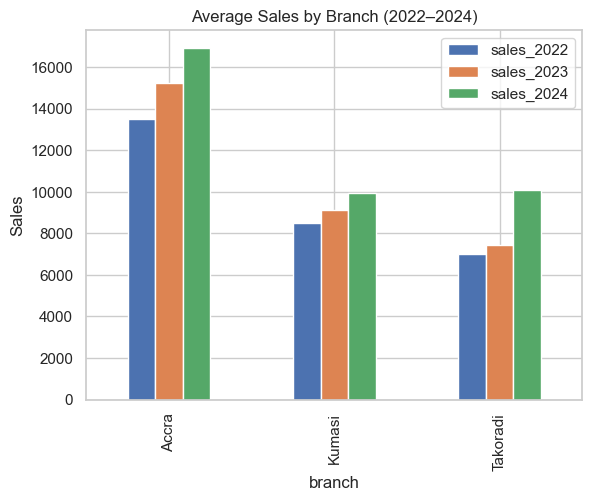

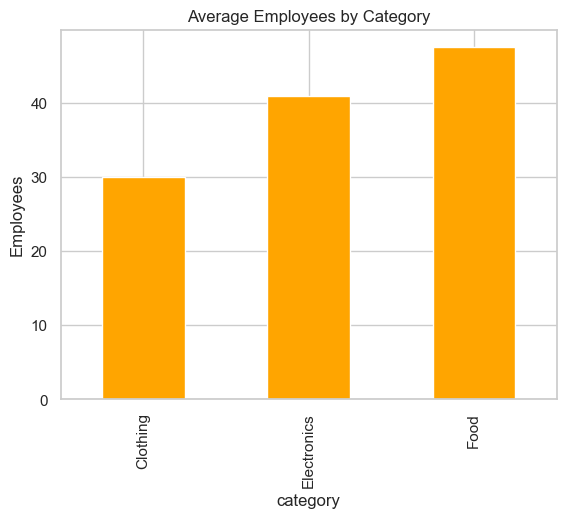

In [45]:
# Sales trend by branch
df.groupby("branch")[["sales_2022","sales_2023","sales_2024"]].mean().plot(kind="bar")
plt.title("Average Sales by Branch (2022–2024)")
plt.ylabel("Sales")
plt.show()

# Employees by category
df.groupby("category")["employees"].mean().plot(kind="bar", color="orange")
plt.title("Average Employees by Category")
plt.ylabel("Employees")
plt.show()

## 📊 Seaborn Visualizations
We now use Seaborn for more advanced and aesthetically pleasing plots:
- Sales trend by branch (2022–2024)
- Employees by category
- Distribution of average sales
- Growth comparison by category

We now visualize all sales (2022, 2023, 2024) against branch using multiple chart types:
- Bar plot (grouped by year)
- Horizontal bar plot
- Pie chart (sales share)
- Line plot (trend across years)
- Box plot (distribution)

1. Sales Trend by Branch (2022–2024)

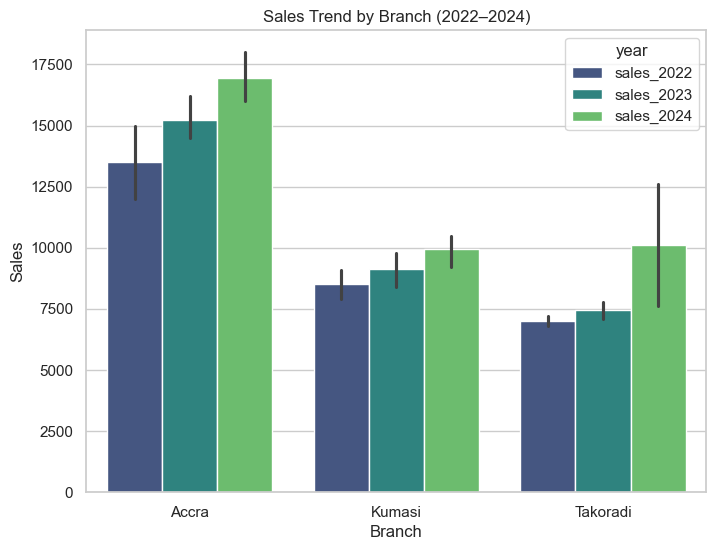

In [46]:
# Melt sales columns into long format for easier plotting
sales_long = df.melt(
    id_vars=["branch"],
    value_vars=["sales_2022", "sales_2023", "sales_2024"],
    var_name="year",
    value_name="sales",
)

plt.figure(figsize=(8, 6))
sns.barplot(data=sales_long, x="branch", y="sales", hue="year", palette="viridis")
plt.title("Sales Trend by Branch (2022–2024)")
plt.ylabel("Sales")
plt.xlabel("Branch")
plt.show()

2. Employees by Category

C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_16280\3963086515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="category", y="employees", palette="magma")


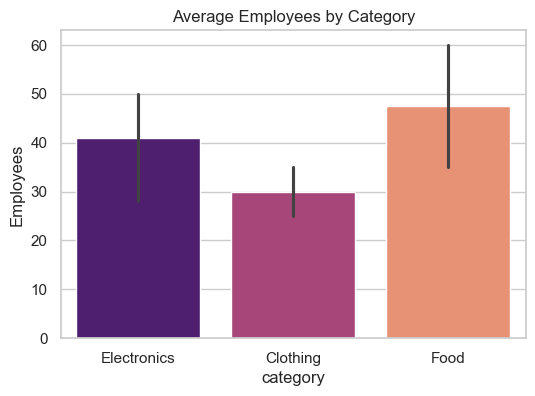

In [47]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="category", y="employees", palette="magma")
plt.title("Average Employees by Category")
plt.ylabel("Employees")
plt.show()

3. Sales Distribution (Histogram + KDE)

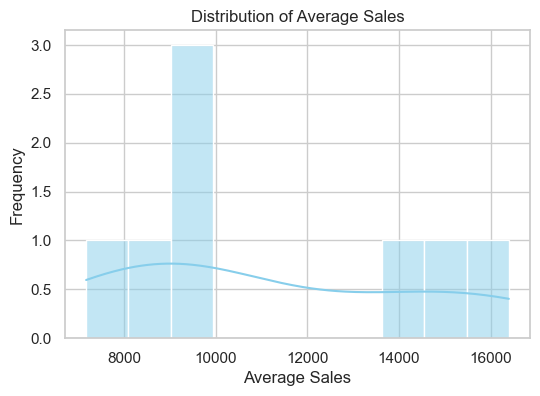

In [48]:
plt.figure(figsize=(6, 4))
sns.histplot(df["avg_sales"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Average Sales")
plt.xlabel("Average Sales")
plt.ylabel("Frequency")
plt.show()

4. Growth Comparison (Boxplot)

C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_16280\3733523929.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="growth_22_24", palette="coolwarm")


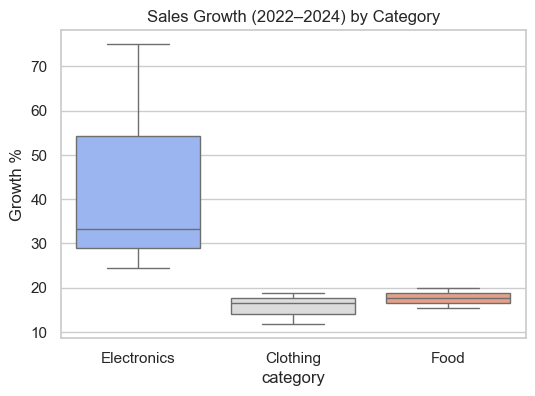

In [49]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="category", y="growth_22_24", palette="coolwarm")
plt.title("Sales Growth (2022–2024) by Category")
plt.ylabel("Growth %")
plt.show()

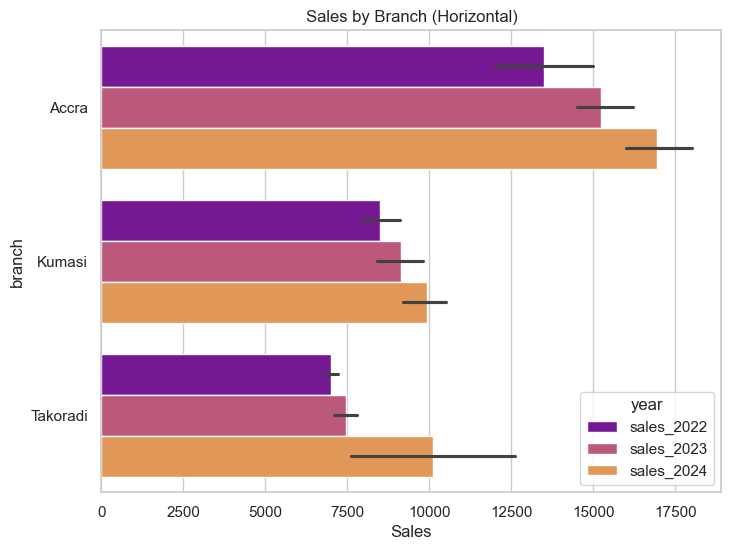

In [50]:
plt.figure(figsize=(8, 6))
sns.barplot(data=sales_long, y="branch", x="sales", hue="year", palette="plasma")
plt.title("Sales by Branch (Horizontal)")
plt.xlabel("Sales")
plt.show()

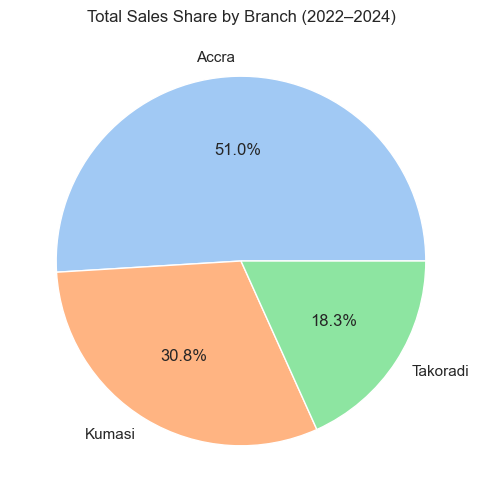

In [51]:
branch_sales = (
    df[["branch", "sales_2022", "sales_2023", "sales_2024"]]
    .groupby("branch")
    .sum()
    .sum(axis=1)
)

plt.figure(figsize=(6, 6))
plt.pie(
    branch_sales,
    labels=branch_sales.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)
plt.title("Total Sales Share by Branch (2022–2024)")
plt.show()

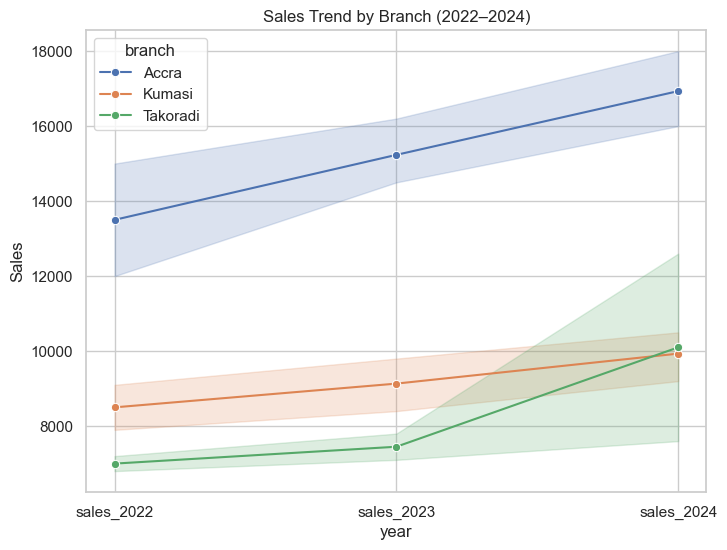

In [52]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=sales_long, x="year", y="sales", hue="branch", marker="o")
plt.title("Sales Trend by Branch (2022–2024)")
plt.ylabel("Sales")
plt.show()

C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_16280\1283705339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sales_long, x="branch", y="sales", palette="coolwarm")


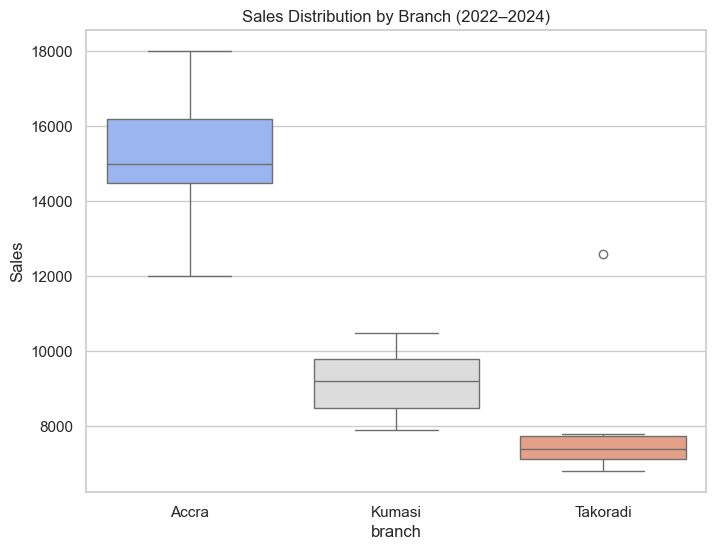

In [53]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=sales_long, x="branch", y="sales", palette="coolwarm")
plt.title("Sales Distribution by Branch (2022–2024)")
plt.ylabel("Sales")
plt.show()

In [54]:
# Sum all sales across years per branch
branch_sales = df.groupby("branch")[["sales_2022", "sales_2023", "sales_2024"]].sum()
branch_sales["total_sales"] = branch_sales.sum(axis=1)
print(branch_sales)

          sales_2022  sales_2023  sales_2024  total_sales
branch                                                   
Accra        40500.0     45700.0     50800.0     137000.0
Kumasi       25500.0     27400.0     29800.0      82700.0
Takoradi     14000.0     14900.0     20200.0      49100.0


C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_16280\1533873101.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_sales.index, y=branch_sales["total_sales"], palette="viridis")


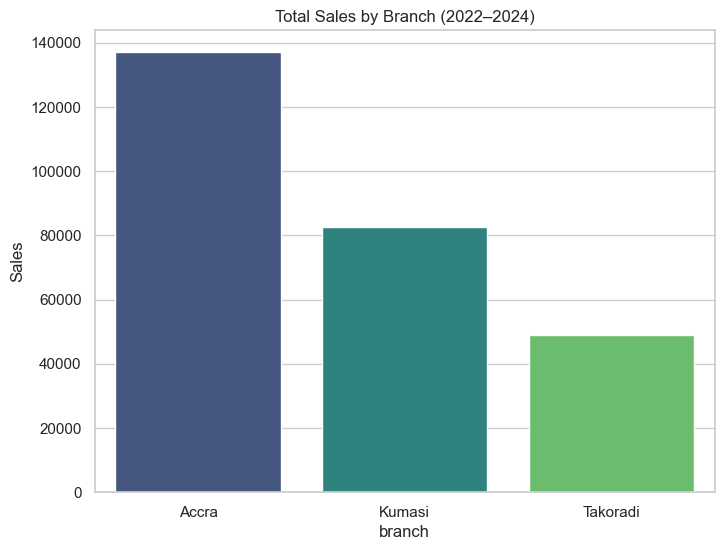

In [55]:
plt.figure(figsize=(8, 6))
sns.barplot(x=branch_sales.index, y=branch_sales["total_sales"], palette="viridis")
plt.title("Total Sales by Branch (2022–2024)")
plt.ylabel("Sales")
plt.show()

C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_16280\2750645774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=branch_sales.index, x=branch_sales["total_sales"], palette="plasma")


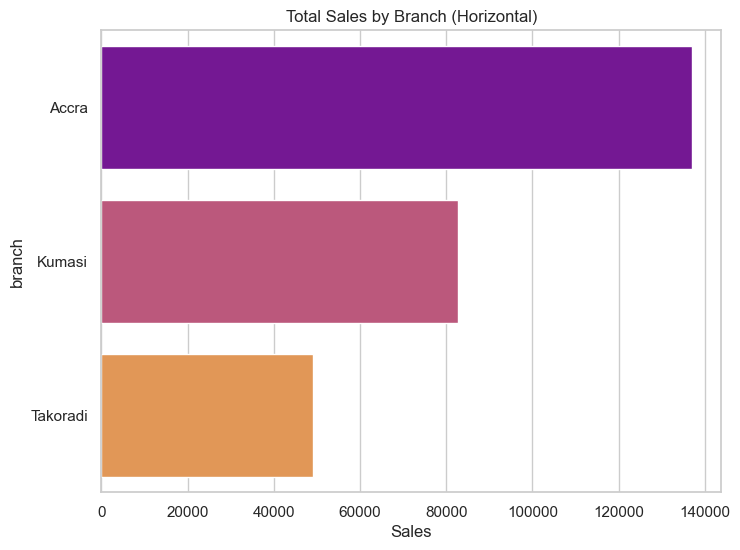

In [56]:
plt.figure(figsize=(8, 6))
sns.barplot(y=branch_sales.index, x=branch_sales["total_sales"], palette="plasma")
plt.title("Total Sales by Branch (Horizontal)")
plt.xlabel("Sales")
plt.show()

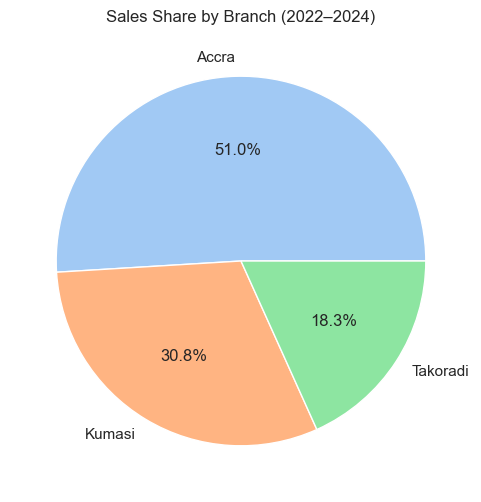

In [57]:
plt.figure(figsize=(6, 6))
plt.pie(
    branch_sales["total_sales"],
    labels=branch_sales.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)
plt.title("Sales Share by Branch (2022–2024)")
plt.show()

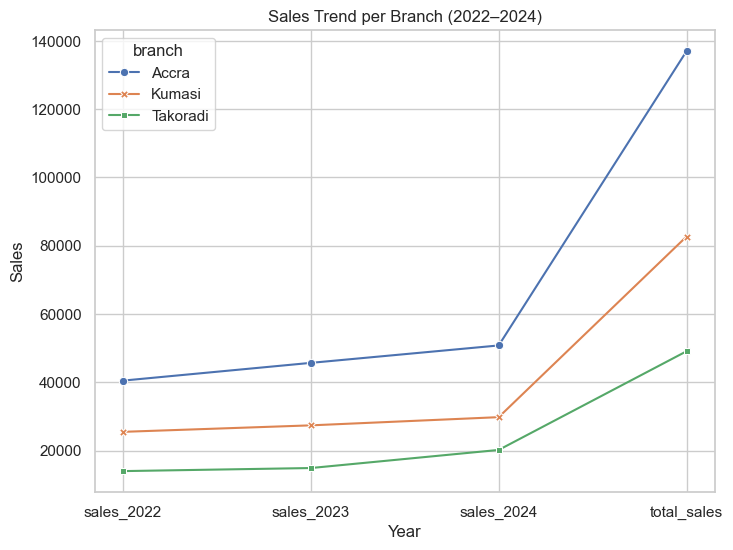

In [58]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=branch_sales.T, markers=True, dashes=False)
plt.title("Sales Trend per Branch (2022–2024)")
plt.ylabel("Sales")
plt.xlabel("Year")
plt.show()

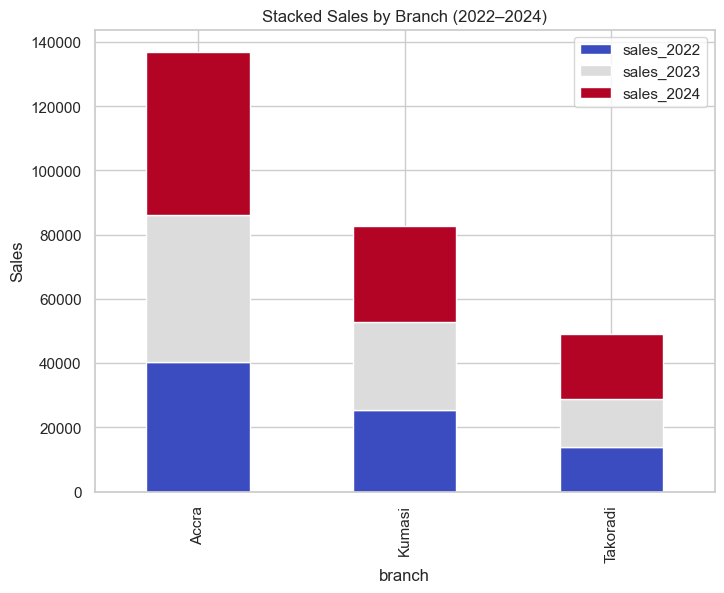

In [59]:
branch_sales_years = df.groupby("branch")[
    ["sales_2022", "sales_2023", "sales_2024"]
].sum()

branch_sales_years.plot(kind="bar", stacked=True, figsize=(8, 6), colormap="coolwarm")
plt.title("Stacked Sales by Branch (2022–2024)")
plt.ylabel("Sales")
plt.show()

In [60]:
# Aggregate employees (sum or average) and sales (sum across years) per branch
branch_summary = df.groupby("branch").agg(
    {"employees": "sum", "sales_2022": "sum", "sales_2023": "sum", "sales_2024": "sum"}
)

# Add total sales column
branch_summary["total_sales"] = branch_summary[
    ["sales_2022", "sales_2023", "sales_2024"]
].sum(axis=1)
print(branch_summary)

          employees  sales_2022  sales_2023  sales_2024  total_sales
branch                                                              
Accra           155     40500.0     45700.0     50800.0     137000.0
Kumasi           90     25500.0     27400.0     29800.0      82700.0
Takoradi         63     14000.0     14900.0     20200.0      49100.0


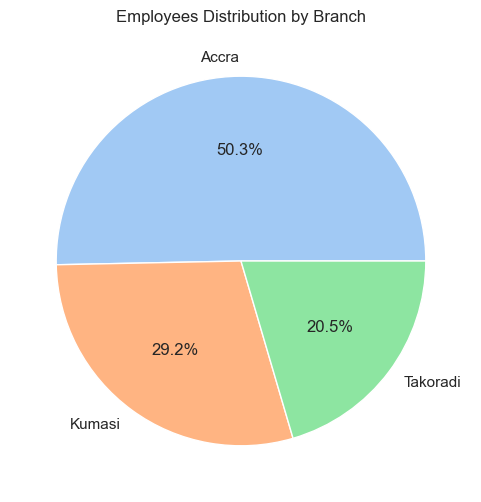

In [61]:
plt.figure(figsize=(6, 6))
plt.pie(
    branch_summary["employees"],
    labels=branch_summary.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)
plt.title("Employees Distribution by Branch")
plt.show()

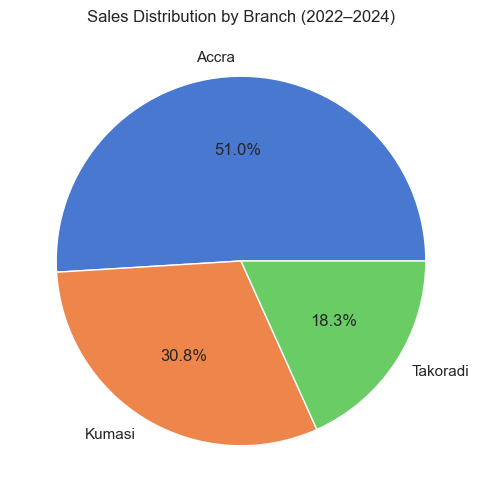

In [62]:
plt.figure(figsize=(6, 6))
plt.pie(
    branch_summary["total_sales"],
    labels=branch_summary.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("muted"),
)
plt.title("Sales Distribution by Branch (2022–2024)")
plt.show()

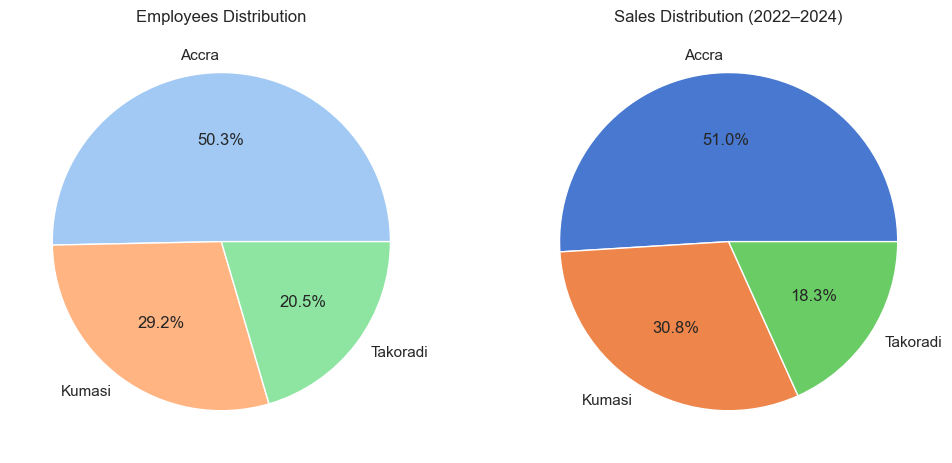

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Employees pie
axes[0].pie(
    branch_summary["employees"],
    labels=branch_summary.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
)
axes[0].set_title("Employees Distribution")

# Sales pie
axes[1].pie(
    branch_summary["total_sales"],
    labels=branch_summary.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("muted"),
)
axes[1].set_title("Sales Distribution (2022–2024)")

plt.show()

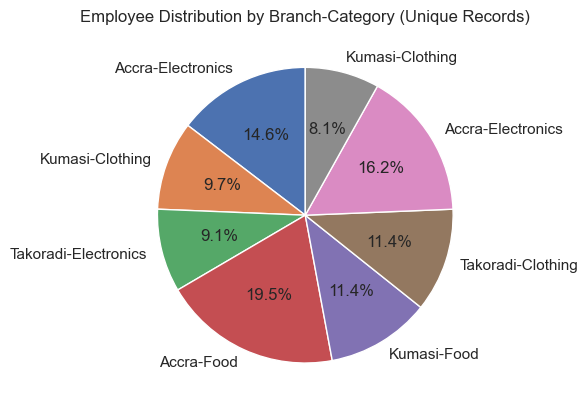

In [64]:
# Create unique labels for each row
df["label"] = df["branch"] + "-" + df["category"]
# Plot pie chart using each row directly
plt.pie(df["employees"], labels=df["label"], autopct="%1.1f%%", startangle=90)
plt.title("Employee Distribution by Branch-Category (Unique Records)")
plt.show()